<a href="https://colab.research.google.com/github/pranav-1205/CSL701-Roll_No_CS47_Machine-Learning-Lab/blob/main/Experiments/Experiment_05_Bagging_ensemble_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 5

 Name : Pranav Vivek Sadwelkar

 Roll No : 47 Batch: CS-03

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Load the dataset
df = pd.read_csv('/content/diabetes.csv')

# Display first 5 records
print("First five records:")
display(df.head())

# Display shape
print("\nDataset Shape:")
print(df.shape)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

First five records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentages:
Outcome
0    65.1
1    34.9
Name: count, dtype: float64


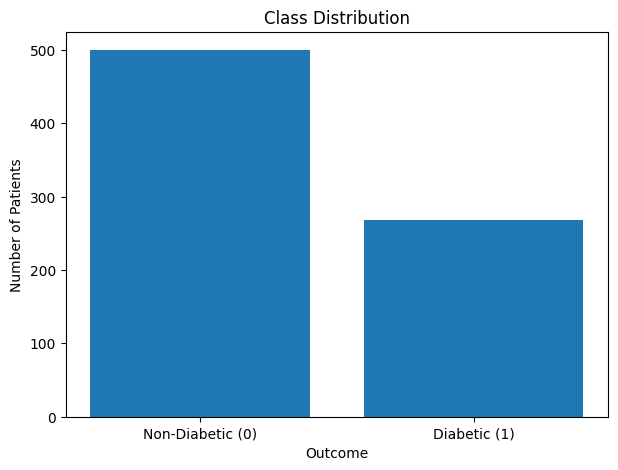

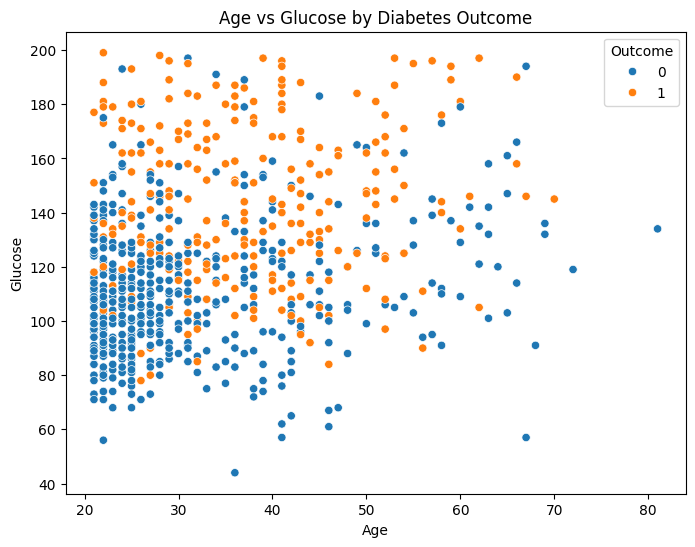

In [3]:
# Count the two classes
class_counts = df['Outcome'].value_counts().sort_index()

# Calculate percentages
class_percentages = (class_counts / len(df)) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages.round(2))

# Bar chart of diabetic and non-diabetic patients
plt.figure(figsize=(7, 5))

plt.bar(
    ['Non-Diabetic (0)', 'Diabetic (1)'],
    class_counts.values
)

plt.xlabel('Outcome')
plt.ylabel('Number of Patients')
plt.title('Class Distribution')

plt.show()

# Scatter Plot of Age vs Glucose
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Glucose',
    hue='Outcome'
)

plt.title('Age vs Glucose by Diabetes Outcome')
plt.xlabel('Age')
plt.ylabel('Glucose')

plt.show()

**Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.**


--> A simple linear decision boundary is insufficient because diabetes depends on multiple features such as glucose, BMI, age, blood pressure and insulin. The diabetic and non-diabetic observations also overlap, so a single straight line cannot clearly separate all the classes.


#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [6]:

## Handling Missing Values
# Features where 0 represents an invalid/missing value
invalid_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Check number of zero values
print("Zero values before replacement:")
print((df[invalid_features] == 0).sum())



## Replace 0 with NaN
# Make a copy of the dataset
df_clean = df.copy()

# Replace invalid zeros with NaN
df_clean[invalid_features] = df_clean[invalid_features].replace(0, np.nan)

print("Missing values after replacing zeros:")
print(df_clean[invalid_features].isnull().sum())



## Fill missing values using median
for column in invalid_features:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Missing values after median imputation:")
print(df_clean.isnull().sum())

Zero values before replacement:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
Missing values after replacing zeros:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [7]:
# Separate features and target
X = df_clean.iloc[:, :8]
y = df_clean.iloc[:, 8]

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training data shape: (614, 8)
Testing data shape : (154, 8)

Training class distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [9]:
# Creating a Bootstrap sampling funtion
def get_bootstrap_sample(X, y):
    n = len(X)

    # Randomly select indices with replacement
    indices = np.random.choice(
        n,
        size=n,
        replace=True
    )

    X_sample = X.iloc[indices]
    y_sample = y.iloc[indices]

    return X_sample, y_sample, indices

# Verify Bootstrap Sampling
np.random.seed(42)

X_boot, y_boot, indices = get_bootstrap_sample(
    X_train,
    y_train
)

unique_indices, counts = np.unique(
    indices,
    return_counts=True
)

duplicate_indices = unique_indices[counts > 1]

all_indices = set(range(len(X_train)))
selected_indices = set(indices)

oob_indices = all_indices - selected_indices

print("Original training samples:", len(X_train))
print("Bootstrap sample size:", len(X_boot))

print("Unique samples in bootstrap:", len(unique_indices))

print("Number of duplicated samples:", len(duplicate_indices))

print("Number of OOB samples:", len(oob_indices))

Original training samples: 614
Bootstrap sample size: 614
Unique samples in bootstrap: 377
Number of duplicated samples: 164
Number of OOB samples: 237


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [10]:
B = 50

ensemble = []

np.random.seed(42)

for b in range(B):

    # Generate bootstrap sample
    X_boot, y_boot, _ = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create decision tree
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=100 + b
    )

    # Train tree
    tree.fit(X_boot, y_boot)

    # Store tree
    ensemble.append(tree)

print("Number of trees in ensemble:", len(ensemble))

Number of trees in ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [12]:
def custom_bagging_predict(ensemble, X_test):

    # Get prediction from every tree
    predictions = np.column_stack([
        tree.predict(X_test)
        for tree in ensemble
    ])

    # Majority voting
    final_predictions = (
        predictions.mean(axis=1) >= 0.5
    ).astype(int)

    return final_predictions
y_pred_bagging = custom_bagging_predict(
ensemble,
X_test
)

print("First 20 Bagging predictions:")
print(y_pred_bagging[:20])

First 20 Bagging predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.


 Single Decision Tree
----------------------------------------
Accuracy : 0.8117
Precision: 0.7451
Recall   : 0.7037
F1-Score : 0.7238

 Custom Bagging
----------------------------------------
Accuracy : 0.8571
Precision: 0.7963
Recall   : 0.7963
F1-Score : 0.7963
Single Decision Tree:
[[87 13]
 [16 38]]

Custom Bagging:
[[89 11]
 [11 43]]


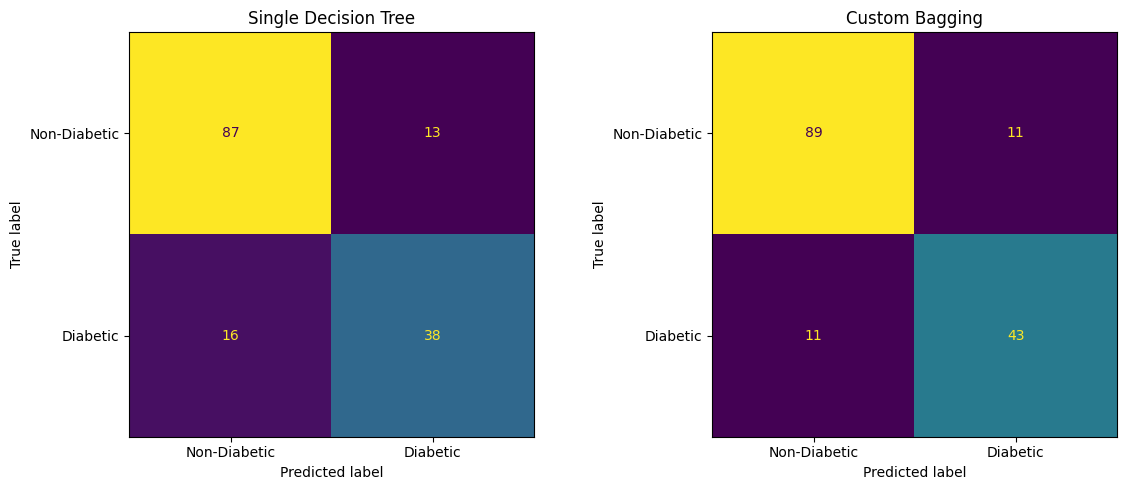

In [15]:
# Train Single Tree
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

y_pred_single = single_tree.predict(X_test)

# Calculate Metrics
def show_metrics(name, y_true, y_pred):

    print("\n", name)
    print("-" * 40)

    print("Accuracy :",
          round(accuracy_score(y_true, y_pred), 4))

    print("Precision:",
          round(precision_score(y_true, y_pred), 4))

    print("Recall   :",
          round(recall_score(y_true, y_pred), 4))

    print("F1-Score :",
          round(f1_score(y_true, y_pred), 4))


show_metrics(
    "Single Decision Tree",
    y_test,
    y_pred_single
)

show_metrics(
    "Custom Bagging",
    y_test,
    y_pred_bagging
)

# Confusion Matrix
cm_single = confusion_matrix(
    y_test,
    y_pred_single
)

cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("Single Decision Tree:")
print(cm_single)

print("\nCustom Bagging:")
print(cm_bagging)

# Plot Graph
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    cm_single,
    display_labels=['Non-Diabetic', 'Diabetic']
).plot(ax=axes[0], colorbar=False)

axes[0].set_title("Single Decision Tree")

ConfusionMatrixDisplay(
    cm_bagging,
    display_labels=['Non-Diabetic', 'Diabetic']
).plot(ax=axes[1], colorbar=False)

axes[1].set_title("Custom Bagging")

plt.tight_layout()
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC: 0.7869
Custom Bagging AUC: 0.9497


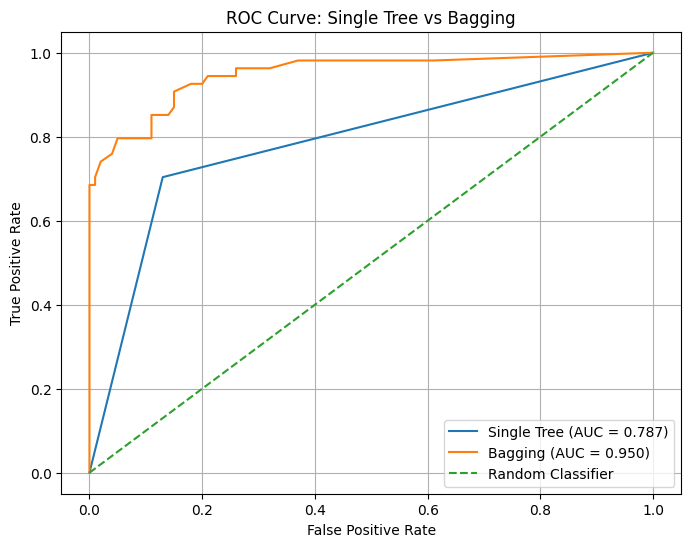

In [17]:
# Getting Probabilities
# Single tree probability
single_prob = single_tree.predict_proba(X_test)[:, 1]

# Average probabilities from all 50 trees
bagging_prob = np.mean(
    [
        tree.predict_proba(X_test)[:, 1]
        for tree in ensemble
    ],
    axis=0
)


#ROC and AUC

fpr_single, tpr_single, _ = roc_curve(
    y_test,
    single_prob
)

fpr_bagging, tpr_bagging, _ = roc_curve(
    y_test,
    bagging_prob
)

auc_single = roc_auc_score(
    y_test,
    single_prob
)

auc_bagging = roc_auc_score(
    y_test,
    bagging_prob
)

print("Single Decision Tree AUC:",
      round(auc_single, 4))

print("Custom Bagging AUC:",
      round(auc_bagging, 4))

# Plotting
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Tree (AUC = {auc_single:.3f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Bagging (AUC = {auc_bagging:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Tree vs Bagging")

plt.legend()
plt.grid()

plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [20]:
from sklearn.ensemble import BaggingClassifier

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)

bagging_model.fit(
    X_train,
    y_train
)

y_pred_sklearn = bagging_model.predict(X_test)

show_metrics(
    "Scikit-Learn Bagging",
    y_test,
    y_pred_sklearn
)

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)

print("\nScikit-Learn Bagging Confusion Matrix:")
print(cm_sklearn)

# Final Comparison Tables
comparison = pd.DataFrame({
    'Model': [
        'Single Decision Tree',
        'Custom Bagging',
        'Scikit-Learn Bagging'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_single),
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_sklearn)
    ],

    'Precision': [
        precision_score(y_test, y_pred_single),
        precision_score(y_test, y_pred_bagging),
        precision_score(y_test, y_pred_sklearn)
    ],

    'Recall': [
        recall_score(y_test, y_pred_single),
        recall_score(y_test, y_pred_bagging),
        recall_score(y_test, y_pred_sklearn)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_single),
        f1_score(y_test, y_pred_bagging),
        f1_score(y_test, y_pred_sklearn)
    ]
})

comparison.round(4)


 Scikit-Learn Bagging
----------------------------------------
Accuracy : 0.8831
Precision: 0.8333
Recall   : 0.8333
F1-Score : 0.8333

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]


,Model,Accuracy,Precision,Recall,F1-Score
0,Single Decision Tree,0.8117,0.7451,0.7037,0.7238
1,Custom Bagging,0.8571,0.7963,0.7963,0.7963
2,Scikit-Learn Bagging,0.8831,0.8333,0.8333,0.8333


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?

####**1. Variance and Stability**

Bagging combines predictions from multiple Decision Trees trained on different bootstrap samples. A single Decision Tree can be sensitive to the particular training data and may therefore have higher variance. Bagging reduces this effect by averaging/combining predictions from many trees, resulting in more stable and consistent performance across different train-test splits.

####**2. Wisdom of Crowds**

Bootstrapping creates different training datasets by randomly sampling the original training data with replacement. Each Decision Tree therefore learns from a slightly different dataset, creating diversity among the models. During prediction, the trees vote on the final class, and the majority vote combines their individual decisions. This consensus can reduce the effect of errors made by individual trees, producing the “Wisdom of Crowds” effect.

####**3. Clinical Interpretation**

False Negatives are especially costly because they represent diabetic patients incorrectly predicted as non-diabetic. Such patients may not receive appropriate further testing or medical attention. Recall measures how many of the actual diabetic patients are correctly identified. Therefore, a higher Recall means fewer diabetic cases are missed. Bagging can provide a more stable prediction by combining multiple trees, and its Recall can be compared with the single Decision Tree to determine whether it reduces false negatives in this experiment.